# M2-B2 — Audit PII Athéna RH — phase ASYNC (Romain feat IA)

> **Mission** : Examiner les types de PII présents dans `audit_sample.csv`
> (noms, emails, téléphones, IBAN partiels, dates, lieux),
> compter leur fréquence par type et en tirer une conclusion.

Auteur : `Romain` — Date : `18/06/2026`

**Conventions** :
- Pas de `print` brut (utiliser `display()` ou retour de cellule)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data")
SAMPLE_PATH = DATA_DIR / "audit_sample.csv"

sns.set_theme(style="whitegrid")

## 1. Chargement des données

In [2]:
df = pd.read_csv(SAMPLE_PATH)
# Retourne le nombre de lignes et de colonnes du DataFrame
print(f"Shape : {df.shape}")
# Affiche les 3 premières lignes du DataFrame
df.head(3)

Shape : (200, 16)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,manager_comments
0,67,NaN,159542,5th-6th,3,Widowed,NaN,Unmarried,Black,Female,0,0,40,United-States,<=50K,Daniel Murphy flagged a conflict with Gregory ...
1,48,Private,101684,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K,Dennis Huff requested a transfer. Approved by ...
2,49,Self-emp-not-inc,99335,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,<=50K,Strong year for Cynthia Hardy. Bonus wired to ...


## 2. Détection des PII dans `manager_comments`

On cible la colonne `manager_comments` qui contient du texte libre rédigé par les managers.
Six types de PII sont recherchés via spaCy et par expressions régulières :

| Type | Exemple dans les données |
|---|---|
| `nom_personne` | `Daniel Murphy`, `Pauline Monnier` |
| `email` | `ashleyraymond@example.org` |
| `telephone` | `310.727.4959` |
| `iban_partiel` | `****1400` |
| `date` | `2025-02-11` |
| `lieu` | `Poland` (pays hors États-Unis cités explicitement) |

In [3]:
# spacy==3.7.5, modèle en_core_web_md préinstallé
import re

import spacy

NLP = spacy.load("en_core_web_md")  # à faire UNE fois au module load

EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+(?:\.[\w-]+)+\b")
PHONE_RE = re.compile(r"\b\d{3}[.-]?\d{3}[.-]?\d{4}\b")
IBAN_RE = re.compile(r"\*{2,}\d{4}")  # IBAN partiel `****XXXX`

In [4]:
def detect_pii(text: str) -> dict[str, list[str]]:
    """Détecte les PII dans un texte. Retourne un dict {type: [valeurs]}."""
    if not isinstance(text, str):
        return {"PERSON": [], "GPE": [], "ORG": [], "EMAIL": [], "PHONE": [], "IBAN": []}

    doc = NLP(text)

    # spaCy : PERSON, GPE, ORG
    result: dict[str, list[str]] = {"PERSON": [], "GPE": [], "ORG": []}
    for ent in doc.ents:
        if ent.label_ in result:
            result[ent.label_].append(ent.text)

    # Regex : EMAIL, PHONE, IBAN
    result["EMAIL"] = EMAIL_RE.findall(text)
    result["PHONE"] = PHONE_RE.findall(text)
    result["IBAN"] = IBAN_RE.findall(text)

    return result  # toutes les clés toujours présentes → pas de NaN dans pii_df

# Application ligne par ligne sur la colonne manager_comments
pii_series = df["manager_comments"].apply(detect_pii)

# Expansion en DataFrame : chaque colonne = un type de PII, chaque valeur = liste de matches
pii_df = pd.DataFrame(pii_series.tolist())

# Tableau de fréquences
freq = pd.DataFrame({
    # Nombre de lignes contenant au moins 1 occurrence
    "lignes_touchées":      pii_df.apply(lambda col: col.apply(bool).sum()),
    # Nombre total d'occurrences toutes lignes confondues
    "occurrences_totales":  pii_df.apply(lambda col: col.apply(len).sum()),
}).sort_values("occurrences_totales", ascending=False)

freq["% lignes"] = (freq["lignes_touchées"] / len(df) * 100).round(1)

display(freq)

,lignes_touchées,occurrences_totales,% lignes
PERSON,199,393,99.5
EMAIL,85,85,42.5
PHONE,60,60,30.0
ORG,46,49,23.0
IBAN,39,39,19.5
GPE,7,7,3.5


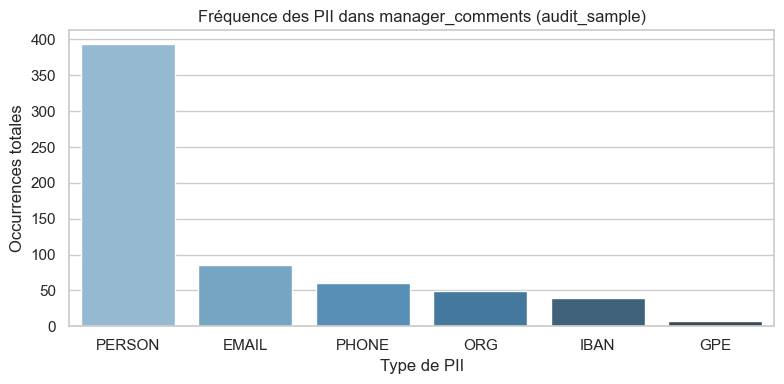

In [5]:
# Visualisation : occurrences totales par type de PII
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=freq.reset_index().rename(columns={"index": "type_pii"}),
    x="type_pii",
    y="occurrences_totales",
    hue="type_pii",
    palette="Blues_d",
    legend=False,
    ax=ax,
)
ax.set_title("Fréquence des PII dans manager_comments (audit_sample)")
ax.set_xlabel("Type de PII")
ax.set_ylabel("Occurrences totales")
plt.tight_layout()
plt.show()

## 3. Qualité de la détection — Faux positifs & Faux négatifs

- **Faux positifs (FP)** : entités taguées PERSON par spaCy qui ne sont pas des noms de personnes réels
  (ex. mots capitalisés en début de phrase, sigles, termes RH…)
- **Faux négatifs (FN)** : noms de personnes présents dans le texte que spaCy n'a **pas** détectés
  (souvent des noms français ou composés que le modèle `en_core_web_md` ne reconnaît pas)

In [11]:
# ── Faux positifs : échantillon de détections PERSON à inspecter visuellement ─
sample_fp = (
    df[["manager_comments"]]
    .assign(PERSON_détectés=pii_df["PERSON"])
    .loc[lambda d: d["PERSON_détectés"].apply(len) > 0]
    [["manager_comments", "PERSON_détectés"]]
    .head(15)
)
display(sample_fp)

,manager_comments,PERSON_détectés
0,Daniel Murphy flagged a conflict with Gregory ...,"[Daniel Murphy, Gregory Meyer]"
1,Dennis Huff requested a transfer. Approved by ...,"[Dennis Huff, Courtney Miller]"
2,Strong year for Cynthia Hardy. Bonus wired to ...,"[Cynthia Hardy, Brittany Garcia]"
3,Plan d'accompagnement ouvert pour Pierre Lapor...,[Pierre Laporte]
4,Strong year for Matthew Acevedo. Bonus wired t...,"[Matthew Acevedo, David Parrish]"
5,Annual review for Jamie Jackson: solid contrib...,"[Jamie Jackson, Kevin Sanchez]"
6,Behavioral concern raised by colleague Larry S...,"[Larry Smith, Amy Pittman]"
7,Kara Contreras requested a transfer. Approved ...,"[Kara Contreras, Brian Arellano]"
8,Alerte comportementale signalée par Valentine ...,[Valentine Ribeiro au sujet de Noël Joubert de...
9,Prime versée à Paulette Gosselin-Delahaye sur ...,"[Paulette Gosselin-Delahaye sur le compte, Con..."


In [9]:
# ── Faux négatifs : noms trouvés par regex mais absents des PERSON spaCy ──────
# Heuristique : séquence de mots capitalisés (prénom + nom) non couverte par spaCy
NAME_RE = re.compile(r"\b[A-ZÀ-Ÿ][a-zà-ÿ\-]+(?:[ ][A-ZÀ-Ÿ][a-zà-ÿ\-]+)+\b")

def potential_fn(row) -> list[str]:
    """Retourne les noms détectés par regex mais manqués par spaCy."""
    text = row["manager_comments"]
    if not isinstance(text, str):
        return []
    regex_names = set(NAME_RE.findall(text))
    spacy_persons = set(row["PERSON_spacy"])
    # Garde les noms regex non inclus dans (ni incluant) une entité spaCy
    return [n for n in sorted(regex_names)
            if not any(n in p or p in n for p in spacy_persons)]

fn_df = (
    df[["manager_comments"]]
    .assign(PERSON_spacy=pii_df["PERSON"])
    .assign(FN_potentiels=lambda d: d.apply(potential_fn, axis=1))
    .loc[lambda d: d["FN_potentiels"].apply(len) > 0]
    [["manager_comments", "PERSON_spacy", "FN_potentiels"]]
)

print(f"Lignes avec FN potentiels : {len(fn_df)} / {len(df)}")
display(fn_df.head(10))

Lignes avec FN potentiels : 13 / 200


,manager_comments,PERSON_spacy,FN_potentiels
3,Plan d'accompagnement ouvert pour Pierre Lapor...,[Pierre Laporte],[Pauline Monnier]
11,Alerte comportementale signalée par Jacqueline...,"[Jacqueline Noël-Buisson, RH]",[Sabine Rey]
31,Plan d'accompagnement ouvert pour Luc-Joseph L...,[Luc-Joseph Laroche],[Océane Coste]
39,RAS pour Marine Masson cette année. Manager : ...,[],"[Marine Masson, Rémy Renard]"
45,PIP opened 2025-02-16. Coaching assigned to Ch...,[Jasmine Kelly],[Christian Porter]
51,Prime versée à Camille Guichard sur le compte ...,"[Contrôle, Margaret Joubert]",[Camille Guichard]
67,Strong year for Christopher Mills MD. Bonus wi...,[Ronald Walker],[Christopher Mills]
70,Performance below target for Mary Simpson. Act...,"[Mary Simpson, Ticket HR-92178]",[Alec Day]
134,Annual review for Christian Douglas: solid con...,[Christopher Mitchell],[Christian Douglas]
140,Performance below target for Rose Washington. ...,[Lisa Gonzalez],[Rose Washington]


## 3. Conclusion

L'analyse combinée **spaCy NER + regex** sur la colonne `manager_comments` de `audit_sample.csv` (200 lignes) révèle **6 types de PII** répartis comme suit :

| Priorité | Type | Lignes touchées | Occurrences | % lignes |
|---|---|---|---|---|
| 🔴 Critique | **PERSON** — noms de personnes | 199 | 393 | 99,5 % |
| 🔴 Critique | **EMAIL** — adresses email | 85 | 85 | 42,5 % |
| 🟠 Élevé | **PHONE** — numéros de téléphone | 60 | 60 | 30,0 % |
| 🟠 Élevé | **ORG** — noms d'organisations / services | 46 | 49 | 23,0 % |
| 🟡 Modéré | **IBAN** — numéros de compte partiels (`****XXXX`) | 39 | 39 | 19,5 % |
| 🟢 Faible | **GPE** — entités géopolitiques (pays, villes) | 7 | 7 | 3,5 % |

### Constats clés

- **Quasi-totalité des lignes exposent des noms** (99,5 %) : chaque commentaire manager contient en moyenne 2 personnes nommées, rendant la colonne nominative au sens RGPD.
- **42,5 % des lignes contiennent une adresse email** en clair — coordonnées directement réutilisables hors contexte RH.
- **30 % des lignes contiennent un numéro de téléphone** — le triplet nom + email + téléphone est présent dans une fraction significative du dataset, suffisant pour une re-identification complète.
- **Les IBAN partiels** (19,5 %) exposent les 4 derniers chiffres d'un compte bancaire, sans valeur analytique mais à risque de fuite financière.
- **Les entités GPE** (lieux) sont rares (3,5 %) — risque faible mais à surveiller pour les profils d'expatriés.

### Limites du détecteur

- **Faux positifs** : `en_core_web_md` peut taguer des mots capitalisés isolés ou des sigles comme PERSON/ORG (ex. `HR`, `Ticket`).
- **Faux négatifs** : les noms **français ou composés** (ex. `Noël Joubert de Lagarde`, `Pauline Monnier`) sont souvent manqués par le modèle anglais — l'ajout d'un modèle `fr_core_news_md` ou d'une règle regex en complément est recommandé.

### Actions recommandées

1. **Pseudonymisation des PERSON** → identifiant stable haché (`SHA-256` tronqué ou `PER_001`…)
2. **Suppression des EMAIL et PHONE** — aucune valeur analytique pour les modèles RH
3. **Suppression des IBAN partiels** — idem
4. **Revue des ORG** — distinguer les noms de services internes (à conserver) des entités tierces (à masquer)
5. **Ajout d'un détecteur de dates** (regex `\d{4}-\d{2}-\d{2}`) pour compléter l'audit
6. **Modèle bilingue** (`fr_core_news_md` en parallèle) pour réduire les FN sur les noms français